# RiskLens AI: Explainable Fraud & Risk Intelligence Platform

## 1. Project Overview

Fraud detection is an operational risk problem, not only a classification task. A model that looks strong on accuracy can still be weak for the business if it misses rare fraud cases or creates more alerts than analysts can review.

This MVP uses the IEEE-CIS Fraud Detection transaction data to build a practical fraud risk workflow. The project combines risk scoring, time-based validation, threshold optimization, explainability, and alert prioritization so the output can support fraud investigation decisions.

The central business question is: Which transactions should be prioritized for fraud investigation, why were they flagged, and what trade-off happens when the fraud alert threshold changes?

## 2. Import Libraries

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.alert_generator import build_alert_queue
from src.data_utils import load_transaction_data
from src.evaluation import calculate_metrics, plot_confusion_matrix, plot_precision_recall_curve, plot_roc_curve
from src.explainability import build_reason_lookup, calculate_shap_values, clean_feature_name, get_top_shap_reasons
from src.feature_engineering import (
    TARGET_COLUMN,
    create_features,
    get_model_feature_columns,
    identify_categorical_features,
    identify_numeric_features,
    get_recommended_raw_columns,
    select_features,
)
from src.model_utils import build_preprocessor, save_artifact, train_model
from src.threshold_optimizer import select_best_threshold, simulate_thresholds

plt.style.use("default")
pd.set_option("display.max_columns", 120)

c:\Users\Anwar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load Data

The MVP uses `train_transaction.csv`. The optional `sample_size` parameter keeps the notebook practical on a normal laptop.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train_transaction.csv"
sample_size = 100000

raw_columns = get_recommended_raw_columns(include_target=True)
data = load_transaction_data(DATA_PATH, sample_size=sample_size, usecols=raw_columns)

print(f"Shape: {data.shape}")
print(f"Fraud ratio: {data[TARGET_COLUMN].mean():.4%}")
display(data.head())
display(pd.DataFrame({"column": data.columns}))
display(data[TARGET_COLUMN].value_counts(normalize=True).rename("share"))
data.info()

Shape: (100000, 105)
Fraud ratio: 3.5760%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
2,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M0,F,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
3,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4,2987012,0,86564,50.0,W,3786,418.0,150.0,visa,226.0,debit,204.0,87.0,NaN,NaN,verizon.net,NaN,4.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,6.0,3.0,72.0,72.0,11.0,107.0,11.0,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,M1,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0


,column
0,TransactionID
1,isFraud
2,TransactionDT
3,TransactionAmt
4,ProductCD
...,...
100,V46
101,V47
102,V48
103,V49


isFraud
0    0.96424
1    0.03576
Name: share, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 105 entries, TransactionID to V50
dtypes: float32(87), int16(1), int32(2), int8(1), object(14)
memory usage: 44.9+ MB


## 4. Exploratory Data Analysis

In [3]:
overall_fraud_rate = data[TARGET_COLUMN].mean()
print(f"Overall fraud rate: {overall_fraud_rate:.4%}")

product_summary = (
    data.groupby("ProductCD")
    .agg(transactions=(TARGET_COLUMN, "size"), fraud_count=(TARGET_COLUMN, "sum"), fraud_rate=(TARGET_COLUMN, "mean"))
    .reset_index()
    .sort_values("fraud_rate", ascending=False)
)
display(product_summary)

Overall fraud rate: 3.5760%


,ProductCD,transactions,fraud_count,fraud_rate
0,C,11528,1409,0.122224
3,S,2068,131,0.063346
1,H,5564,266,0.047807
2,R,6374,250,0.039222
4,W,74466,1520,0.020412


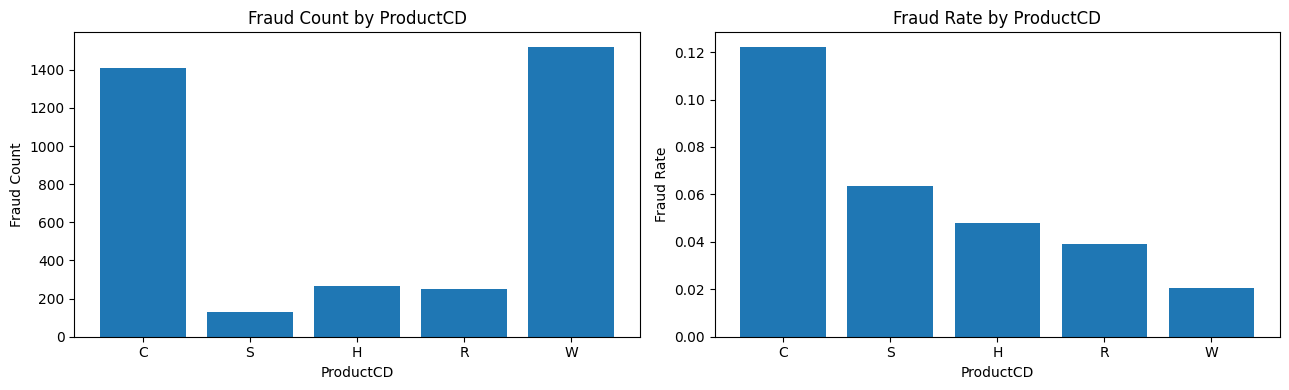

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(product_summary["ProductCD"], product_summary["fraud_count"])
axes[0].set_title("Fraud Count by ProductCD")
axes[0].set_xlabel("ProductCD")
axes[0].set_ylabel("Fraud Count")

axes[1].bar(product_summary["ProductCD"], product_summary["fraud_rate"])
axes[1].set_title("Fraud Rate by ProductCD")
axes[1].set_xlabel("ProductCD")
axes[1].set_ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

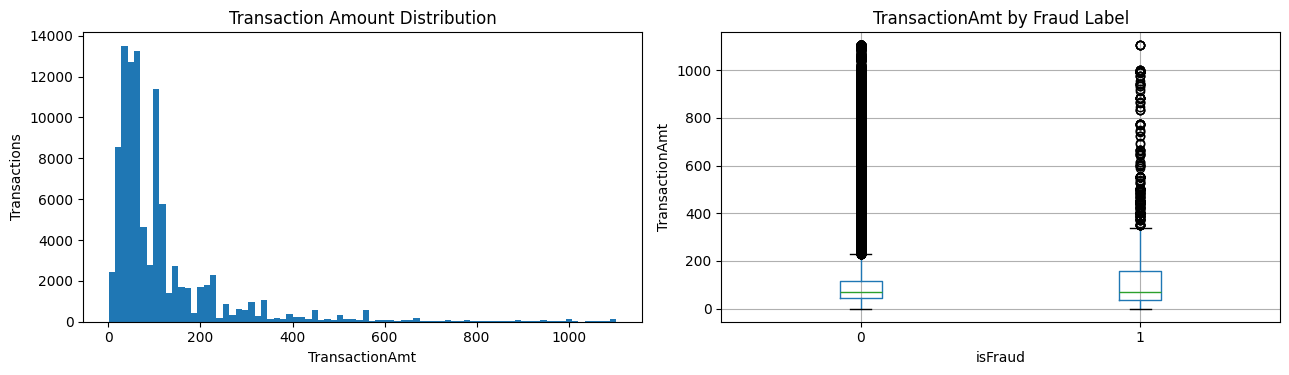

In [5]:
amount_cap = data["TransactionAmt"].quantile(0.99)
amount_plot_data = data.loc[data["TransactionAmt"] <= amount_cap, ["TransactionAmt", TARGET_COLUMN]].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(amount_plot_data["TransactionAmt"], bins=80)
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("TransactionAmt")
axes[0].set_ylabel("Transactions")

amount_plot_data.boxplot(column="TransactionAmt", by=TARGET_COLUMN, ax=axes[1])
axes[1].set_title("TransactionAmt by Fraud Label")
axes[1].set_xlabel("isFraud")
axes[1].set_ylabel("TransactionAmt")
fig.suptitle("")
plt.tight_layout()
plt.show()

,column,missing_share
0,dist2,0.93671
1,D7,0.93359
2,D13,0.89605
3,D14,0.89480
4,D12,0.89116
5,D6,0.87664
6,D9,0.87232
7,D8,0.87232
8,R_emaildomain,0.76769
9,dist1,0.59650


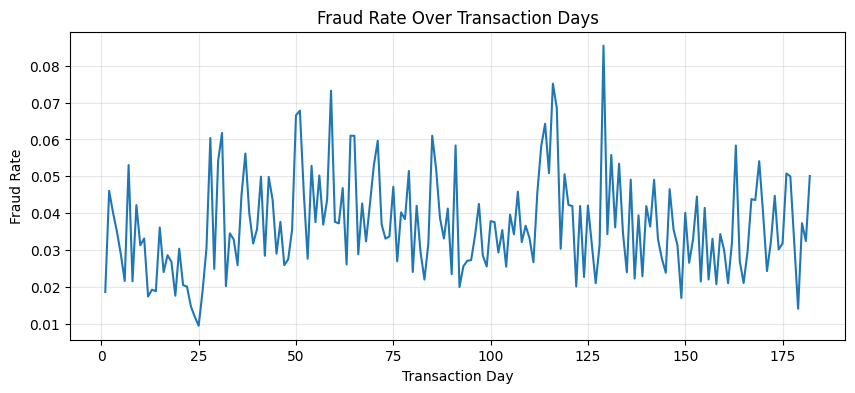

In [6]:
missing_summary = (
    data.isna().mean().sort_values(ascending=False).head(20).rename("missing_share").reset_index().rename(columns={"index": "column"})
)
display(missing_summary)

time_pattern = data.assign(transaction_day=data["TransactionDT"] // (3600 * 24)).groupby("transaction_day").agg(
    transactions=(TARGET_COLUMN, "size"), fraud_rate=(TARGET_COLUMN, "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_pattern["transaction_day"], time_pattern["fraud_rate"])
ax.set_title("Fraud Rate Over Transaction Days")
ax.set_xlabel("Transaction Day")
ax.set_ylabel("Fraud Rate")
ax.grid(alpha=0.3)
plt.show()

## 5. Feature Selection

The MVP uses a practical subset of transaction columns rather than all available V columns. This keeps the workflow easier to understand and faster to run.

In [7]:
selected_data = select_features(data)
print(f"Selected shape: {selected_data.shape}")
display(pd.DataFrame({"selected_column": selected_data.columns}))

Selected shape: (100000, 105)


,selected_column
0,TransactionID
1,TransactionDT
2,TransactionAmt
3,ProductCD
4,card1
...,...
100,V47
101,V48
102,V49
103,V50


## 6. Feature Engineering

The engineered features support time patterns, amount risk, missingness signals, and email consistency.

In [8]:
model_data, amount_high_threshold = create_features(selected_data)
categorical_features = identify_categorical_features(model_data)
numeric_features = identify_numeric_features(model_data)
feature_columns = get_model_feature_columns(model_data)

print(f"High amount threshold: {amount_high_threshold:,.2f}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
display(model_data.head())

High amount threshold: 441.95
Numeric features: 97
Categorical features: 14


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,isFraud,transaction_hour,transaction_day,log_transaction_amt,is_high_amount,missing_count,email_domain_match,card_missing_count,address_missing_count
0,2987000,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,4.241327,0,33,0,1,1
1,2987002,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0,1,4.094345,0,12,0,0,1
2,2987006,86522,159.0,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M0,F,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0,1,5.075174,0,12,0,0,1
3,2987007,86529,422.5,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0,1,6.048553,0,31,0,0,2
4,2987012,86564,50.0,W,3786,418.0,150.0,visa,226.0,debit,204.0,87.0,NaN,NaN,verizon.net,NaN,4.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,6.0,3.0,72.0,72.0,11.0,107.0,11.0,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,NaN,107.0,NaN,NaN,NaN,M1,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0,0,1,3.931826,0,28,0,0,2


## 7. Train Validation Split

Fraud models should be validated in a way that resembles future deployment. A time-based split trains on earlier transactions and validates on later transactions, which is more realistic than a random split for fraud behavior.

In [9]:
model_data = model_data.sort_values("TransactionDT").reset_index(drop=True)
split_index = int(len(model_data) * 0.80)

train_df = model_data.iloc[:split_index].copy()
valid_df = model_data.iloc[split_index:].copy()

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]
X_valid = valid_df[feature_columns]
y_valid = valid_df[TARGET_COLUMN]

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {valid_df.shape}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Validation fraud rate: {y_valid.mean():.4%}")

Train shape: (80000, 113)
Validation shape: (20000, 113)
Train fraud rate: 3.6062%
Validation fraud rate: 3.4550%


## 8. Model Development

Two models are trained: a baseline logistic regression model and a main LightGBM model. The main model uses class imbalance handling through `scale_pos_weight`.

In [10]:
baseline_preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=True)
X_train_baseline = baseline_preprocessor.fit_transform(X_train)
X_valid_baseline = baseline_preprocessor.transform(X_valid)

baseline_model = train_model(X_train_baseline, y_train, model_type="logistic_regression")
baseline_scores = baseline_model.predict_proba(X_valid_baseline)[:, 1]
baseline_metrics = calculate_metrics(y_valid, baseline_scores, threshold=0.50)
display(pd.Series(baseline_metrics, name="baseline_logistic_regression"))

roc_auc                                0.829231
pr_auc                                 0.274258
precision                              0.083692
recall                                 0.816208
f1_score                               0.151817
confusion_matrix    [[13134, 6175], [127, 564]]
threshold                                   0.5
Name: baseline_logistic_regression, dtype: object

In [11]:
preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=False)
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

model = train_model(X_train_processed, y_train, model_type="lightgbm")
valid_scores = model.predict_proba(X_valid_processed)[:, 1]
default_metrics = calculate_metrics(y_valid, valid_scores, threshold=0.50)
display(pd.Series(default_metrics, name="lightgbm_default_threshold"))

c:\Users\Anwar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


roc_auc                                0.889426
pr_auc                                 0.454671
precision                               0.20787
recall                                 0.649783
f1_score                               0.314977
confusion_matrix    [[17598, 1711], [242, 449]]
threshold                                   0.5
Name: lightgbm_default_threshold, dtype: object

## 9. Model Evaluation

Fraud data is highly imbalanced, so accuracy is not the main metric. ROC-AUC and PR-AUC show ranking quality, while precision, recall, F1-score, and the confusion matrix show operational behavior at a chosen threshold.

roc_auc                                0.889426
pr_auc                                 0.454671
precision                               0.20787
recall                                 0.649783
f1_score                               0.314977
confusion_matrix    [[17598, 1711], [242, 449]]
threshold                                   0.5
dtype: object

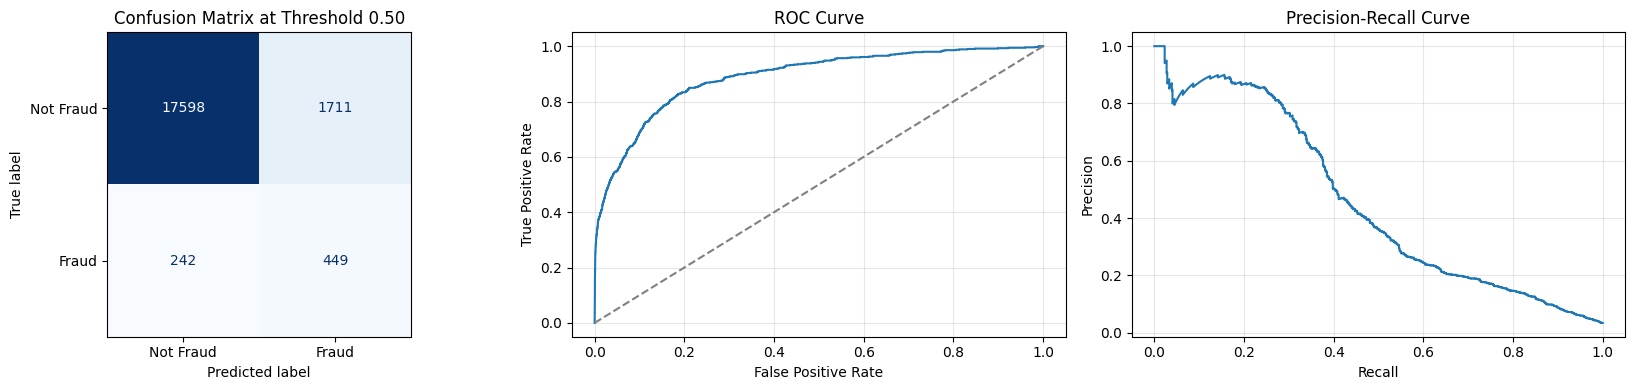

In [12]:
display(pd.Series(default_metrics))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
plot_confusion_matrix(y_valid, valid_scores, threshold=0.50, ax=axes[0])
plot_roc_curve(y_valid, valid_scores, ax=axes[1])
plot_precision_recall_curve(y_valid, valid_scores, ax=axes[2])
plt.tight_layout()
plt.show()

## 10. Threshold Optimization

The threshold simulator estimates the business effect of changing the alert threshold. Fraud loss is represented by `TransactionAmt`, investigation cost is set to 5 USD per flagged transaction, and net benefit is captured fraud amount minus investigation cost.

In [13]:
threshold_results = simulate_thresholds(
    y_true=y_valid,
    y_scores=valid_scores,
    transaction_amounts=valid_df["TransactionAmt"],
    investigation_cost_per_alert=5.0,
)
recommended_threshold = select_best_threshold(threshold_results)
recommended_row = threshold_results.loc[threshold_results["threshold"] == recommended_threshold].iloc[0]

print(f"Recommended threshold: {recommended_threshold:.2f}")
display(threshold_results)

Recommended threshold: 0.30


,threshold,true_positives,false_positives,true_negatives,false_negatives,precision,recall,flagged_transactions,estimated_fraud_amount_captured,investigation_cost,estimated_missed_fraud_loss,estimated_net_benefit
0,0.05,674,13526,5783,17,0.047465,0.975398,14200,100297.609375,71000.0,1172.550049,29297.609375
1,0.10,654,9888,9421,37,0.062038,0.946454,10542,99133.718750,52710.0,2336.442871,46423.718750
2,0.15,632,7426,11883,59,0.078431,0.914616,8058,94550.156250,40290.0,6920.012207,54260.156250
3,0.20,615,5803,13506,76,0.095824,0.890014,6418,90405.023438,32090.0,11065.141602,58315.023438
4,0.25,596,4695,14614,95,0.112644,0.862518,5291,85563.406250,26455.0,15906.751953,59108.406250
5,0.30,576,3817,15492,115,0.131118,0.833575,4393,82490.953125,21965.0,18979.218750,60525.953125
6,0.35,547,3147,16162,144,0.148078,0.791606,3694,78209.218750,18470.0,23260.947266,59739.218750
7,0.40,522,2578,16731,169,0.168387,0.755427,3100,75008.812500,15500.0,26461.347656,59508.812500
8,0.45,487,2086,17223,204,0.189273,0.704776,2573,64663.054688,12865.0,36807.101562,51798.054688
9,0.50,449,1711,17598,242,0.207870,0.649783,2160,59599.316406,10800.0,41870.843750,48799.316406


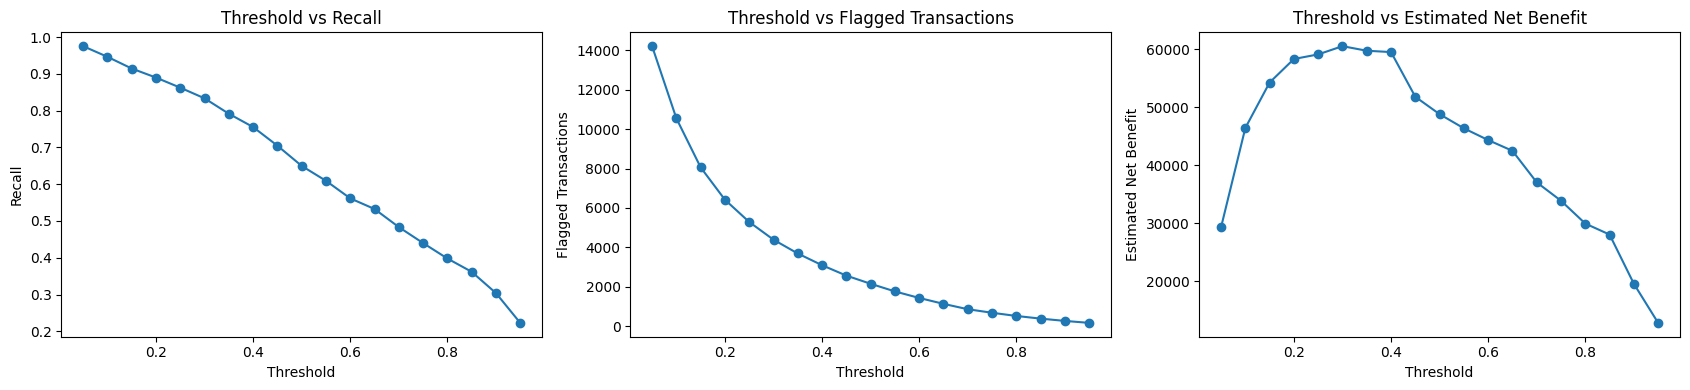

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(threshold_results["threshold"], threshold_results["recall"], marker="o")
axes[0].set_title("Threshold vs Recall")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Recall")

axes[1].plot(threshold_results["threshold"], threshold_results["flagged_transactions"], marker="o")
axes[1].set_title("Threshold vs Flagged Transactions")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Flagged Transactions")

axes[2].plot(threshold_results["threshold"], threshold_results["estimated_net_benefit"], marker="o")
axes[2].set_title("Threshold vs Estimated Net Benefit")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Estimated Net Benefit")
plt.tight_layout()
plt.show()

## 11. Explainability with SHAP

SHAP is used on a small high-risk validation sample to keep runtime practical. Global importance summarizes broad model drivers, and local explanations provide top risk drivers for selected transactions.

c:\Users\Anwar\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,mean_abs_shap
5,C14,0.473973
0,C1,0.467429
4,C13,0.318710
21,D2,0.289563
41,TransactionAmt,0.242822
22,D3,0.231371
86,V49,0.217563
9,C5,0.214262
101,card6,0.202764
40,R_emaildomain,0.186792


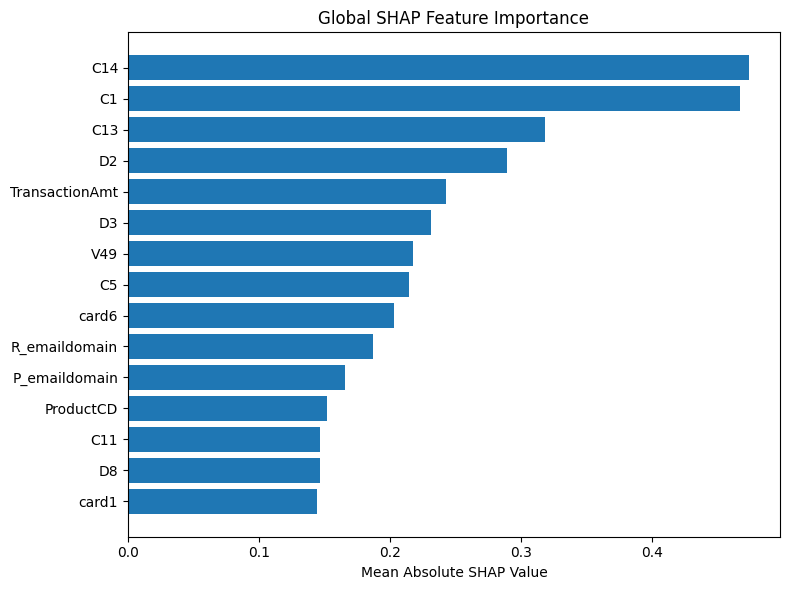

In [15]:
explanation_sample_size = min(1000, len(X_valid))
score_series = pd.Series(valid_scores, index=X_valid.index)
explain_indices = score_series.sort_values(ascending=False).head(explanation_sample_size).index
X_explain = X_valid.loc[explain_indices]

shap_values, transformed_feature_names = calculate_shap_values(model, preprocessor, X_explain)

importance = pd.DataFrame(
    {
        "feature": [clean_feature_name(name, categorical_features) for name in transformed_feature_names],
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }
)
global_importance = importance.groupby("feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
display(global_importance.head(20))

fig, ax = plt.subplots(figsize=(8, 6))
top_global = global_importance.head(15).sort_values("mean_abs_shap")
ax.barh(top_global["feature"], top_global["mean_abs_shap"])
ax.set_title("Global SHAP Feature Importance")
ax.set_xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

In [16]:
reason_lookup = build_reason_lookup(
    valid_df.loc[explain_indices, "TransactionID"],
    shap_values,
    transformed_feature_names,
    top_n=3,
    categorical_features=categorical_features,
)
default_reasons = global_importance["feature"].head(3).tolist()

for index in explain_indices[:5]:
    transaction_id = int(valid_df.loc[index, "TransactionID"])
    risk_score = score_series.loc[index]
    top_reasons = reason_lookup[transaction_id]
    print(f"TransactionID: {transaction_id}")
    print(f"Risk Score: {risk_score:.2f}")
    print("Top Risk Drivers:")
    for rank, reason in enumerate(top_reasons, start=1):
        print(f"{rank}. {reason}")
    print("")

TransactionID: 3495231
Risk Score: 1.00
Top Risk Drivers:
1. C1
2. V45
3. C14

TransactionID: 3463900
Risk Score: 1.00
Top Risk Drivers:
1. C1
2. V45
3. C12

TransactionID: 3471989
Risk Score: 1.00
Top Risk Drivers:
1. C1
2. V45
3. V44

TransactionID: 3494143
Risk Score: 1.00
Top Risk Drivers:
1. C1
2. V45
3. C14

TransactionID: 3494147
Risk Score: 1.00
Top Risk Drivers:
1. V45
2. C1
3. C14



## 12. Fraud Alert Queue

The alert queue converts model scores into a review list for analysts. High, medium, and low risk levels determine recommended action.

In [17]:
alert_queue = build_alert_queue(
    validation_data=valid_df,
    risk_scores=valid_scores,
    recommended_threshold=recommended_threshold,
    reason_lookup=reason_lookup,
    default_reasons=default_reasons,
)
display(alert_queue.head(20))

,TransactionID,risk_score,risk_level,TransactionAmt,ProductCD,predicted_fraud,actual_isFraud,top_reason_1,top_reason_2,top_reason_3,recommended_action,analyst_note
0,3495231,0.998286,High,39.592999,C,1,1,C1,V45,C14,Review immediately,This transaction received a fraud risk score o...
1,3463900,0.997969,High,44.265999,C,1,1,C1,V45,C12,Review immediately,This transaction received a fraud risk score o...
2,3471989,0.997968,High,45.925999,C,1,1,C1,V45,V44,Review immediately,This transaction received a fraud risk score o...
3,3494143,0.997592,High,39.592999,C,1,1,C1,V45,C14,Review immediately,This transaction received a fraud risk score o...
4,3494147,0.997549,High,39.592999,C,1,1,V45,C1,C14,Review immediately,This transaction received a fraud risk score o...
5,3540434,0.997416,High,54.224998,C,1,1,C1,V45,C12,Review immediately,This transaction received a fraud risk score o...
6,3495229,0.997183,High,39.592999,C,1,1,V45,C1,C14,Review immediately,This transaction received a fraud risk score o...
7,3543616,0.997183,High,29.818001,C,1,1,C1,V45,C13,Review immediately,This transaction received a fraud risk score o...
8,3522631,0.997127,High,66.398003,C,1,1,C1,V45,C12,Review immediately,This transaction received a fraud risk score o...
9,3522630,0.996941,High,66.398003,C,1,1,C1,V45,C12,Review immediately,This transaction received a fraud risk score o...


## 13. Save Outputs

In [18]:
models_dir = PROJECT_ROOT / "models"
outputs_dir = PROJECT_ROOT / "outputs"
models_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

recommended_metrics = calculate_metrics(y_valid, valid_scores, threshold=recommended_threshold)
metrics_summary = {
    **recommended_metrics,
    "recommended_threshold": recommended_threshold,
    "total_validation_transactions": int(len(valid_df)),
    "validation_fraud_rate": float(y_valid.mean()),
    "recommended_alerts": int(recommended_row["flagged_transactions"]),
    "estimated_fraud_amount_captured": float(recommended_row["estimated_fraud_amount_captured"]),
    "estimated_net_benefit": float(recommended_row["estimated_net_benefit"]),
    "baseline_roc_auc": baseline_metrics["roc_auc"],
    "baseline_pr_auc": baseline_metrics["pr_auc"],
}

save_artifact(model, models_dir / "fraud_model.pkl")
save_artifact(preprocessor, models_dir / "preprocessor.pkl")
save_artifact(feature_columns, models_dir / "feature_columns.pkl")

threshold_results.to_csv(outputs_dir / "threshold_results.csv", index=False)
alert_queue.to_csv(outputs_dir / "fraud_alert_queue.csv", index=False)
with (outputs_dir / "metrics_summary.json").open("w", encoding="utf-8") as file:
    json.dump(metrics_summary, file, indent=2)

display(pd.Series(metrics_summary))

roc_auc                                               0.889426
pr_auc                                                0.454671
precision                                             0.131118
recall                                                0.833575
f1_score                                              0.226593
confusion_matrix                   [[15492, 3817], [115, 576]]
threshold                                                  0.3
recommended_threshold                                      0.3
total_validation_transactions                            20000
validation_fraud_rate                                  0.03455
recommended_alerts                                        4393
estimated_fraud_amount_captured                   82490.953125
estimated_net_benefit                             60525.953125
baseline_roc_auc                                      0.829231
baseline_pr_auc                                       0.274258
dtype: object

## 14. Key Findings

RiskLens AI produces transaction-level fraud risk scores and turns them into an analyst-ready alert queue. The LightGBM model ranks transactions by risk, while SHAP explanations highlight the features that drive high-risk cases.

Threshold selection matters because fraud teams operate with limited review capacity. A lower threshold can capture more fraud but creates more false positives and investigation cost. A higher threshold reduces workload but can miss more fraud loss.

The alert queue helps analysts prioritize work by combining risk score, risk level, top reasons, recommended action, and a template-based analyst note.

Limitations of this MVP include simplified cost assumptions, use of `train_transaction.csv` only, no production inference service, no drift monitoring, and no retraining workflow. Planned improvements include identity data integration, Evidently AI monitoring, FastAPI serving, Docker packaging, Gemini-powered analyst summaries, and scheduled retraining.